# 2D JI-SRT-ERT Gauss Newton Inversion Example

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt

import pygimli as pg
import pygimli.meshtools as mt
from pygimli.physics import ert
import pygimli.physics.traveltime as tt
from pygimli.viewer.mpl import drawStreams
world = mt.createWorld(
    start=[-50, 0], end=[50, -50], layers=[-1, -5],
    worldMarker=True)
block = mt.createCircle(
    pos=[-5, -3.], radius=[4, 1], marker=4,
    boundaryMarker=10, area=0.1)
poly = mt.createPolygon([(1,-4), (2,-1.5), (4,-2), (5,-2),
                         (8,-3), (5,-3.5), (3,-4.5)], isClosed=True,
                         addNodes=3, interpolate='spline', marker=5)
geom = world + block + poly
scheme = ert.createData(elecs=np.linspace(start=-15, stop=15, num=21),
                           schemeName='dd')
schemeTT = tt.createRAData(scheme.sensors())
for p in scheme.sensors():
    geom.createNode(p)
    geom.createNode(p - [0, 0.1])

# Create a mesh for the finite element modelling with appropriate mesh quality.
mesh_fwd = mt.createMesh(geom, quality=34)

# Create a map to set resistivity values in the appropriate regions
# [[regionNumber, resistivity], [regionNumber, resistivity], [...]
rhomap = [[1, 100.],
          [2, 75.],
          [3, 50.],
          [4, 150.],
          [5, 25]]

velmap = [[1, 500.],
          [2, 1500.],
          [3, 2500.],
          [4, 4000.],
          [5, 300]]

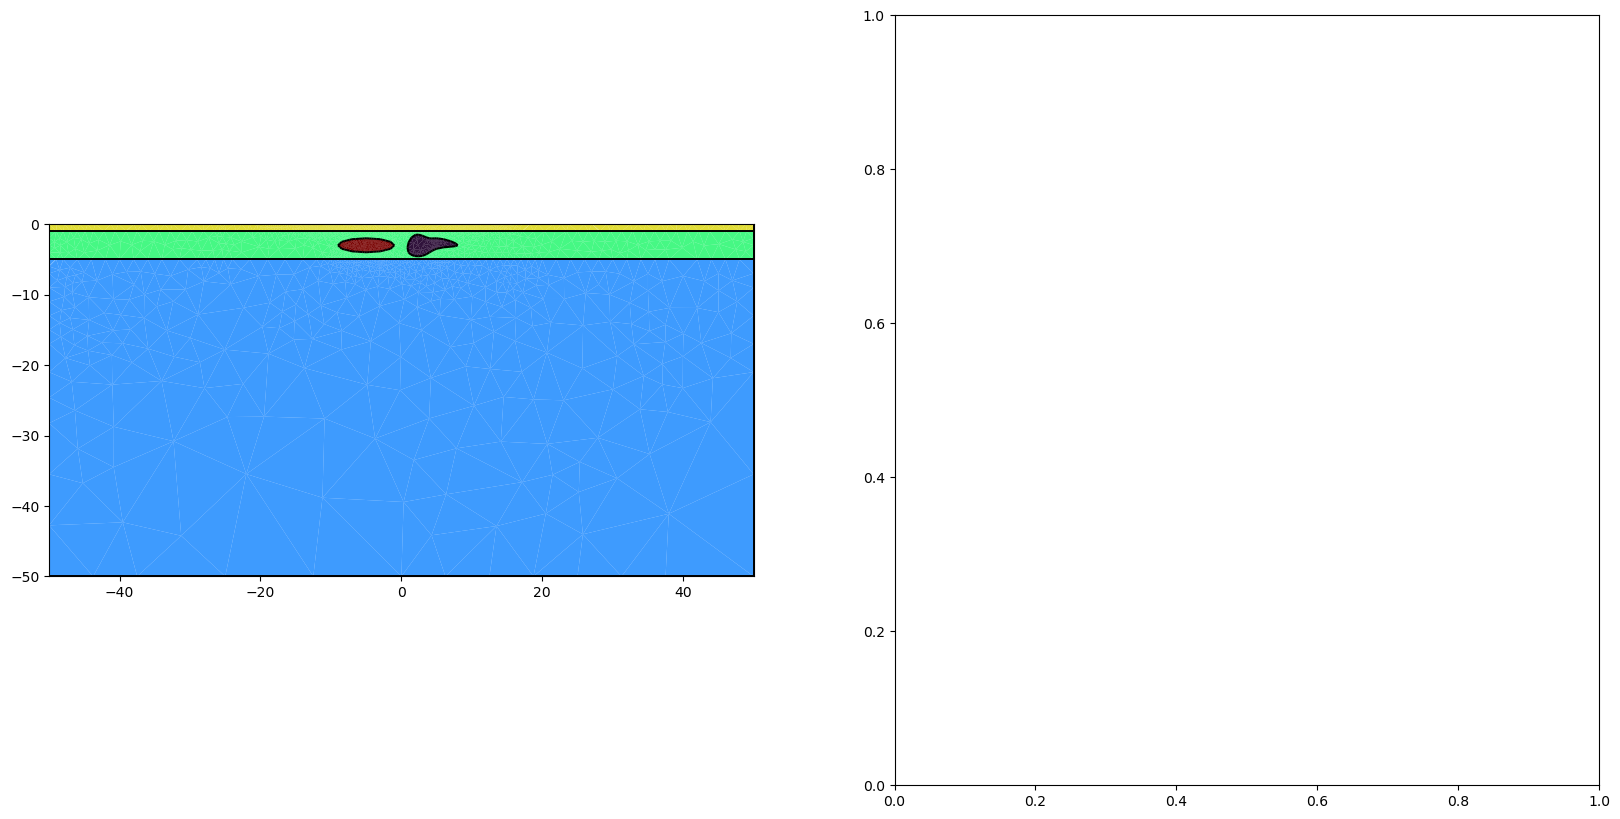

/home/alexubuntuwsl/anaconda3/envs/pg/lib/python3.11/site-packages/pygimli/viewer/mpl/colorbar.py:321: UserWarning: Adding colorbar to a different Figure <Figure size 2000x1000 with 3 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = cbarTarget.colorbar(gci, cax=cax, orientation=orientation)
/home/alexubuntuwsl/anaconda3/envs/pg/lib/python3.11/site-packages/pygimli/viewer/mpl/colorbar.py:321: UserWarning: Adding colorbar to a different Figure <Figure size 2000x1000 with 4 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = cbarTarget.colorbar(gci, cax=cax, orientation=orientation)


<Figure size 640x480 with 0 Axes>

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
pg.show(mesh_fwd, data=rhomap, ax=ax1, label='ρ [Ωm]', pad=0.5, cMap='turbo', showMesh=False)
pg.show(mesh_fwd, data=velmap, ax=ax2, label='v [m/s]', pad=0.5, cMap='magma', showMesh=False)
plt.show()

In [3]:
data_ERT = ert.simulate(mesh_fwd, scheme=scheme, res=rhomap, noiseLevel=1,
                    noiseAbs=1e-6, seed=1337)

data_ERT.remove(data_ERT['rhoa'] < 0)
#pg.info('Filtered rhoa (min/max)', min(data['rhoa']), max(data['rhoa']))
vp = pg.solver.parseMapToCellArray(velmap, mesh_fwd)
data_SRT = tt.simulate(slowness=1.0 / vp, scheme=schemeTT, mesh=mesh_fwd,
                   noiseLevel=0.001, noiseAbs=0.001, seed=1337, verbose=True)

# You can save the data for further use
data_ERT.save('simple.dat')
mgr = ert.ERTManager('simple.dat')
plc = mt.createParaMeshPLC(data_ERT, paraDepth=15, paraMaxCellSize=3, paraBoundary=5, boundary=1)
mesh = mt.createMesh(plc, quality=34.3)

11/09/26 - 00:12:15 - pyGIMLi - INFO - Data error estimate (min:max)  0.010000294838286121 : 0.01056761917552525


11/09/26 - 00:12:15 - pyGIMLi - INFO - Creating refined mesh (secnodes: 2) to solve forward task.


ModellingBase::setMesh() copying new mesh ... Found datafile: 21 electrodes
Found: 21 free-electrodes
rMin = 0.75, rMax = 60
NGauLeg + NGauLag for inverse Fouriertransformation: 11 + 4
Found non-Neumann domain
0.0585421 s
FOP updating mesh dependencies ... 3.4825e-05 s
Calculating response for model: min = 25 max = relativeError set to a value > 0.5 .. assuming this is a percentage Error level dividing them by 100
150
Allocating memory for primary potential...... 0.00304371

No primary potential for secondary field calculation. Calculating analytically...
Forward: time: 0.31056s
Response: min = 43.6475 max = 102.718 mean = 71.3742
Reciprocity rms(modelReciprocity) 0.140597%, max: 0.449979%
min/max t: 0.003 0.019682262270470208


(<Axes: xlabel='$x$ in m', ylabel='Depth in m'>, None)

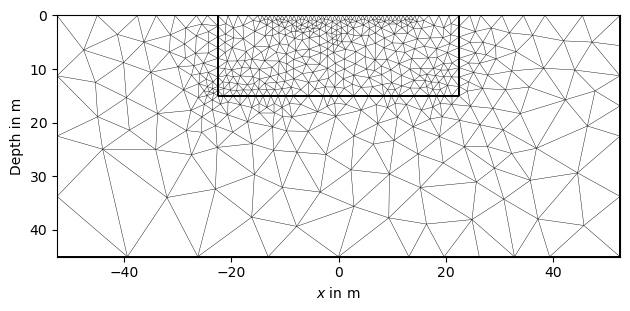

In [4]:
pg.show(mesh, markers=False)

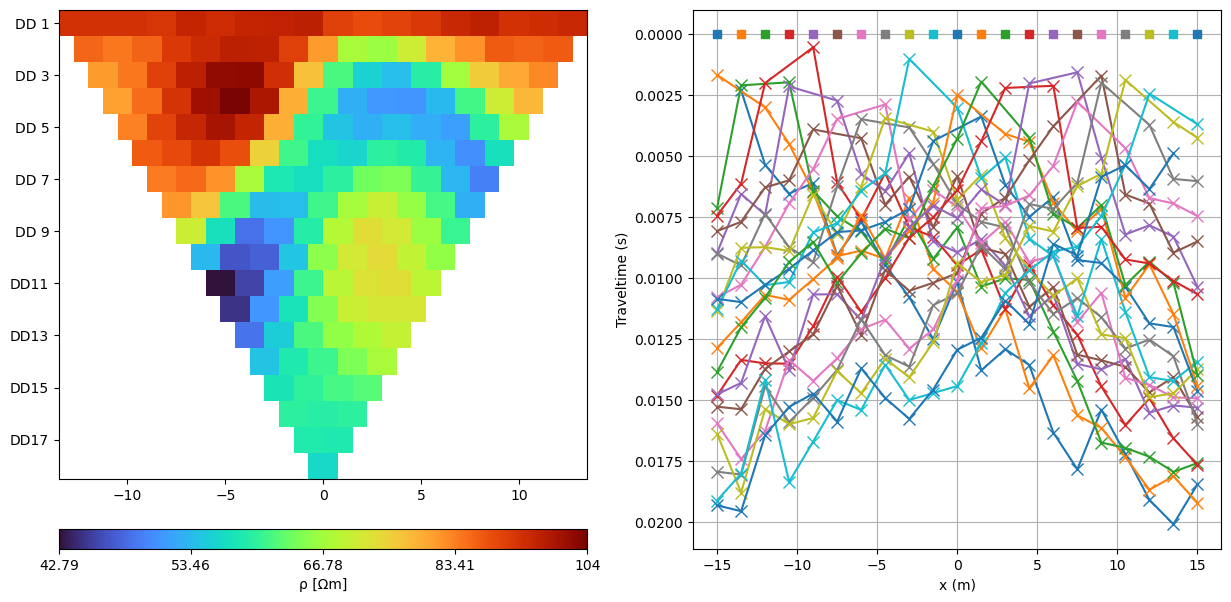

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
pg.show(data_ERT, ax=ax1, label='ρ [Ωm]', cMap='turbo', showMesh=False)
tt.show(data_SRT, ax=ax2, label='v [m/s]')

In [6]:
mgr_ERT = ert.ERTManager(data_ERT)
mgr_ERT.setMesh(mesh)
#pg.show(mgr_ERT.paraDomain)

11/09/26 - 00:12:18 - pyGIMLi - INFO - Found 2 regions.
11/09/26 - 00:12:18 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.


In [7]:
inv_ERT = mgr_ERT.invert(maxIter=20, mesh=mesh, verbose=True)

11/09/26 - 00:12:18 - pyGIMLi - INFO - Found 2 regions.
11/09/26 - 00:12:18 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
11/09/26 - 00:12:18 - pyGIMLi - INFO - Creating forward mesh from region infos.
11/09/26 - 00:12:18 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
11/09/26 - 00:12:18 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 2091 Cells: 4016 Boundaries: 3094
11/09/26 - 00:12:18 - pyGIMLi - INFO - Use median(data values)=67.9439561191829
11/09/26 - 00:12:18 - pyGIMLi - INFO - Created startmodel from forward operator:614, min/max=67.943956/67.943956
11/09/26 - 00:12:18 - pyGIMLi - INFO - Starting inversion.


min/max(dweight) = 94.6287/99.9971
fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x7d334afd4130>
Data transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
Model transformation: Logarithmic transform
min/max (data): 42.79/104
min/max (error): 1%/1.06%
min/max (start model): 67.94/67.94
--------------------------------------------------------------------------------
Calculating response for model: min = 67.944 max = 67.944
Allocating memory for primary potential...... 0.000419441

No primary potential for secondary field calculation. Calculating analytically...
Forward: time: 0.141575s
Response: min = 67.7421 max = 68.0324 mean = 67.8983
Reciprocity rms(modelReciprocity) 0%, max: 0%
min/max(dweight) = 94.6287/99.9971
Building constraints matrix
constraint matrix of size(nBounds x nModel) 876 x 614
check Jacobian: wrong dimensions: (0x0) should be (171x614)  force: 1
jacobian size invalid, forced recalc: 1
Calculating Jacobian matrix (forced=1)...Usin

(<Axes: xlabel='$x$ in m', ylabel='Depth in m'>,
 <matplotlib.colorbar.Colorbar at 0x7d3340f37c50>)

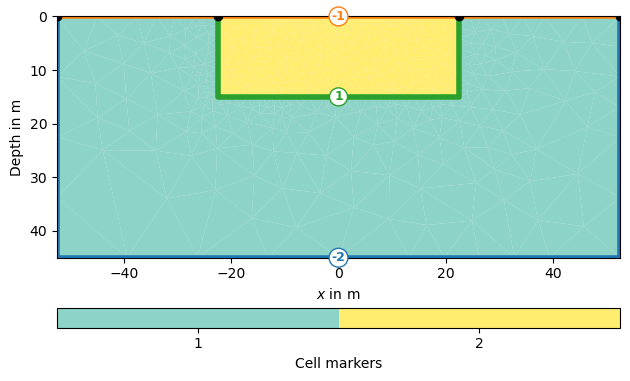

In [8]:
pg.show(mgr_ERT.mesh, markers=True)

In [9]:
meshSRT = mgr_ERT.paraDomain
for c in meshSRT.cells():
    c.setMarker(2)
mgr_SRT = tt.TravelTimeManager(data_SRT)
inv_SRT = mgr_SRT.invert(mesh=meshSRT,maxIter=20, verbose=True)

11/09/26 - 00:12:19 - pyGIMLi - INFO - Found 1 regions.
11/09/26 - 00:12:19 - pyGIMLi - INFO - Creating forward mesh from region infos.
11/09/26 - 00:12:19 - pyGIMLi - INFO - Creating refined mesh (secnodes: 2) to solve forward task.
11/09/26 - 00:12:19 - pyGIMLi - INFO - Create gradient starting model. 500: 5000
11/09/26 - 00:12:19 - pyGIMLi - INFO - Created startmodel from forward operator:614, min/max=0.000200/0.002000
11/09/26 - 00:12:19 - pyGIMLi - INFO - Starting inversion.


min/max(dweight) = 980.698/997.009
fop: <pygimli.physics.traveltime.modelling.TravelTimeDijkstraModelling object at 0x7d3340d9e340>
Data transformation: Identity transform
Model transformation: Logarithmic transform
min/max (data): 5.4e-04/0.02
min/max (error): 5.08%/187%
min/max (start model): 2.0e-04/0.002
--------------------------------------------------------------------------------
min/max(dweight) = 980.698/997.009
Building constraints matrix
constraint matrix of size(nBounds x nModel) 876 x 614
check Jacobian: wrong dimensions: (0x0) should be (420x614)  force: 1
jacobian size invalid, forced recalc: 1
Calculating Jacobian matrix (forced=1)...inv.iter 0 ... chi² =    4.66
--------------------------------------------------------------------------------
inv.iter 1 ... ... 0.191477 s
min data = 0.000536213 max data = 0.0200743 (420)
min error = 0.0507653 max error = 1.87053 (420)
min response = 0.0028241 max response = 0.0191634 (420)
calc without reference model
0: rms/rrms(data,

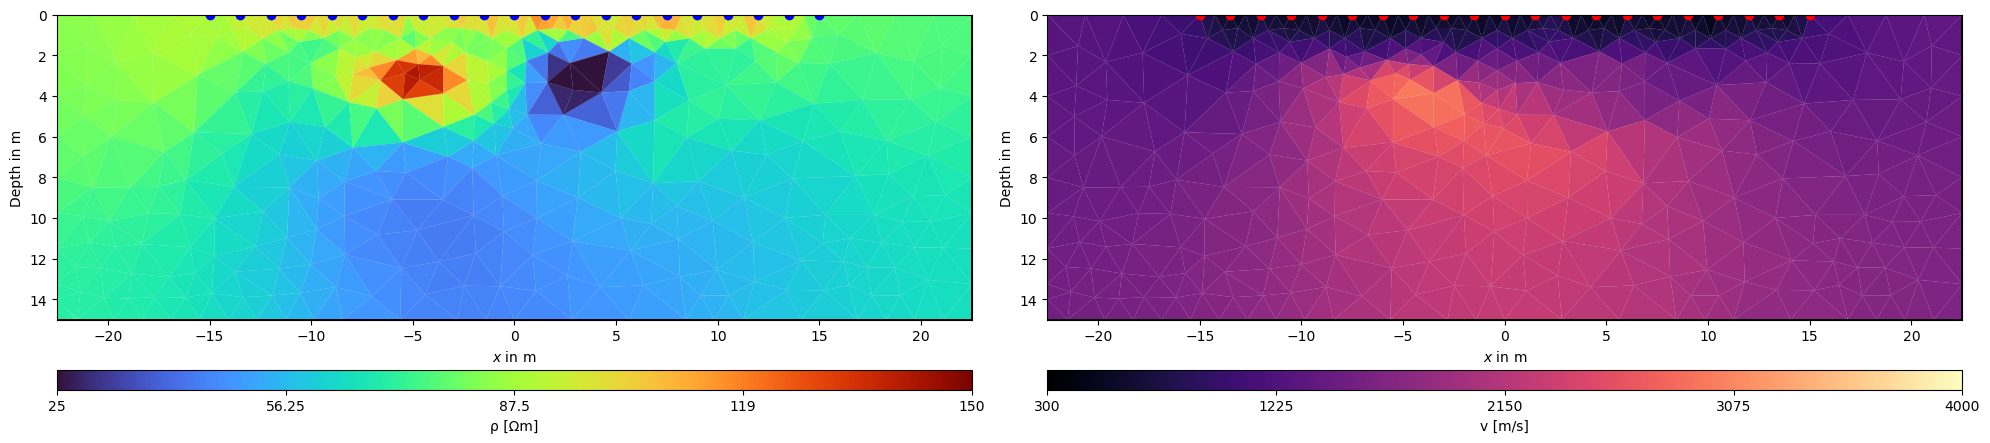

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
pg.show(mgr_ERT.paraDomain, data=inv_ERT, ax=ax1, label='ρ [Ωm]', cMap='turbo', cMin=25, cMax=150,showMesh=False)
pg.show(mgr_SRT.paraDomain, data=inv_SRT, ax=ax2, label='v [m/s]', cMap='magma', cMin=300, cMax=4000, showMesh=False)
ax1.scatter(scheme.sensors()[:,0], scheme.sensors()[:,1], color='blue')
ax2.scatter(schemeTT.sensors()[:,0], schemeTT.sensors()[:,1], color='red')

In [17]:
import jointtools.JItools as JI

crossfop = JI.crossGradient(
    fopList=[mgr_ERT.fop, mgr_SRT.fop], 
    dataList=[data_ERT['rhoa'], data_SRT['t']], 
    errorList=[data_ERT['err'], data_SRT['err']/data_SRT['t']], 
    meshList=[mesh, meshSRT],
    alpha = 1,
    smooth = True
    )

11/09/26 - 00:13:21 - pyGIMLi - INFO - Found 2 regions.
11/09/26 - 00:13:21 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.
11/09/26 - 00:13:21 - pyGIMLi - INFO - Creating forward mesh from region infos.
11/09/26 - 00:13:21 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
11/09/26 - 00:13:21 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 2091 Cells: 4016 Boundaries: 3094
11/09/26 - 00:13:22 - pyGIMLi - INFO - Found 1 regions.
11/09/26 - 00:13:22 - pyGIMLi - INFO - Creating forward mesh from region infos.


Reset region parameter
RegionManager copying mesh ...0.00772899 s 
create NeighborInfos ... 6.2946e-05 s 
analysing mesh ... 2 regions.
creating para domain ... 0.00386724 s
creating para domain ... 0.00314774 s
ModellingBase::setMesh() copying new mesh ... Found datafile: 21 electrodes
Found: 21 node-electrodes
Found non-Neumann domain
 updateMeshDependency:: cleaning primpot
0.0315157 s
FOP updating mesh dependencies ... 3.1654e-05 s
ModellingBase::setMesh() copying new mesh ... 0.036797 s
FOP updating mesh dependencies ... 7.6845e-05 s


11/09/26 - 00:13:22 - pyGIMLi - INFO - Creating refined mesh (secnodes: 2) to solve forward task.


ModellingBase::setMesh() copying new mesh ... 0.00803011 s
FOP updating mesh dependencies ... 5.2492e-05 s


In [18]:
dataVec = np.concatenate((np.array(data_ERT['rhoa']), np.array(data_SRT['t'])))
errorVec = np.concatenate((np.array(data_ERT['err']), np.array(data_SRT['err']/data_SRT['t'])))

11/09/26 - 00:13:24 - pyGIMLi - INFO - Use median(data values)=67.9439561191829
11/09/26 - 00:13:24 - pyGIMLi - INFO - Create gradient starting model. 500: 5000


Using existing subpotentials for createJacobian.
Subpotentials matrix is empty.
Calculating subpotentials analytical for createJacobian: 1 (top: 0|cem: 0|het: 0)
Allocating memory for primary potential...... 0.000666088

No primary potential for secondary field calculation. Calculating analytically...
Forward: time: 0.111948s
Scale subpotentials with 67.944
S(14/14-std::mt): 0.00377242:time: 0.149179s
sens sum: median = 1.01992 min = 0.96754 max = 1.12839
Cells have different markers - region of interest are cells with non minimum marker


(<Axes: >, <matplotlib.colorbar.Colorbar at 0x7d334057d550>)

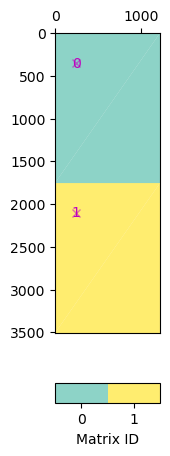

In [19]:
startmodel_ERT = mgr_ERT.fop.createStartModel(data_ERT['rhoa'])
startmodel_SRT = mgr_SRT.fop.createStartModel(data_SRT['t'])

startmodel = np.concatenate([startmodel_ERT,startmodel_SRT])

crossfop.createJacobian(startmodel)
pg.show(crossfop.constraints())

In [20]:
import pygimli.frameworks.inversion as inversion
inv = inversion.GaussNewtonInversion(fop=crossfop)
modelGN = inv.run(dataVals=dataVec, errorVals=errorVec, startModel=startmodel)
print('Final \u03C7\u00B2 = ', inv.chi2())

Calculating response for model: min = 67.944 max = 67.944
Using existing primary potentials.
Forward: time: 0.407602s
Response: min = 67.7421 max = 68.0324 mean = 67.8983
Reciprocity rms(modelReciprocity) 0%, max: 0%
Cells have different markers - region of interest are cells with non minimum marker


/home/alexubuntuwsl/Arbeitsplatz Linux/nsg26/nsg26/CrossGradient_Alex/jointtools/spatialgradient/spatialgradient.py:70: RuntimeWarning: invalid value encountered in subtract
  rhs = np.array(model[neighbour_cells]) - model_value


Using existing subpotentials for createJacobian.
S(14/14-std::mt): 0.000462084:time: 0.193079s
sens sum: median = 1.01992 min = 0.96754 max = 1.12839
Cells have different markers - region of interest are cells with non minimum marker
dM:  1228 [0.5096177166768728,...,0.22368964267585412]
Calculating response for model: min = 22.0433 max = 162.724
Using existing primary potentials.
Forward: time: 0.446148s
Response: min = 40.0712 max = 112.837 mean = 70.8518
Reciprocity rms(modelReciprocity) 0.50931%, max: 1.67545%
Cells have different markers - region of interest are cells with non minimum marker
Cells have different markers - region of interest are cells with non minimum marker
Cells have different markers - region of interest are cells with non minimum marker
Cells have different markers - region of interest are cells with non minimum marker
Cells have different markers - region of interest are cells with non minimum marker
Cells have different markers - region of interest are cells 

(<Axes: xlabel='$x$ in m', ylabel='Depth in m'>,
 <matplotlib.colorbar.Colorbar at 0x7d333bfeb210>)

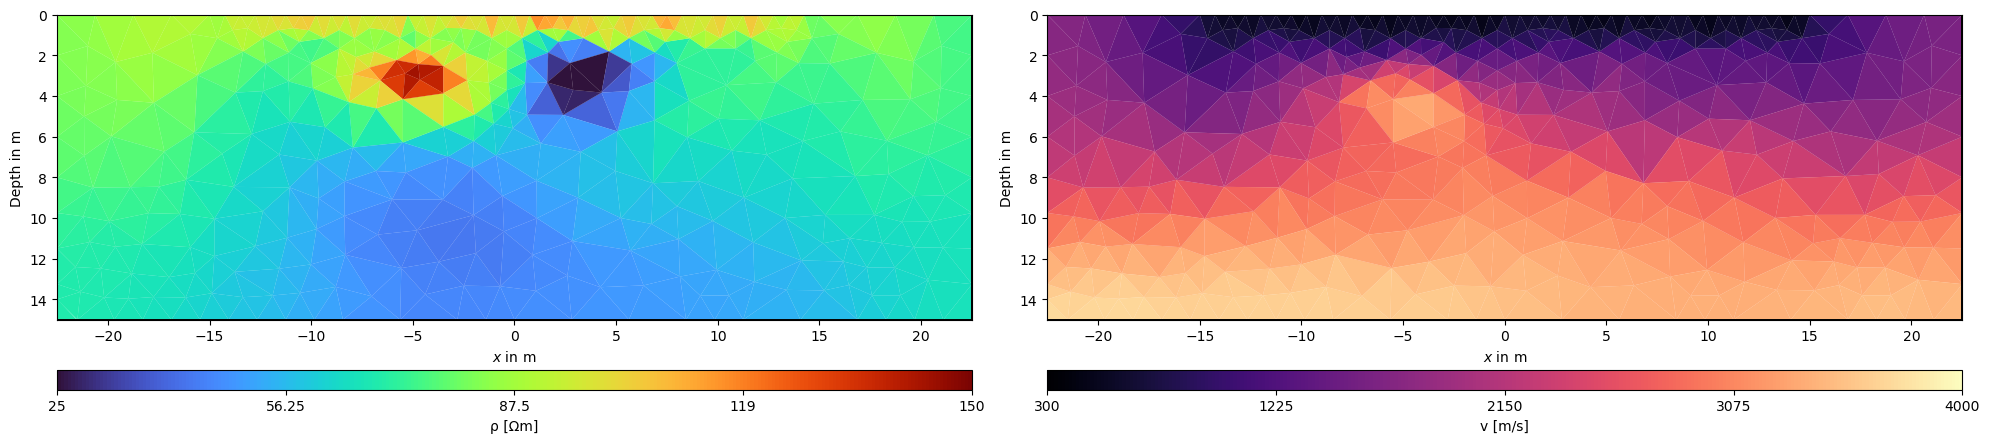

In [22]:
fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(20, 10))
pg.show(meshSRT, data=np.split(modelGN,2)[0], ax=ax1, cMap='turbo', cMin=25, cMax=150, label='ρ [Ωm]', colorBar=True,  logScale=False)
pg.show(meshSRT, data=1/np.split(modelGN,2)[1], ax=ax2, cMap='magma', cMin=300, cMax=4000, label='v [m/s]', colorBar=True,  logScale=False)